In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs

In [2]:
ds_interior = xr.open_zarr("../data/datastore.interior.zarr")
ds_boundary = xr.open_zarr("../data/datastore.boundary.zarr")

# Delete attribute section as it contains each grid index as a string
# making the loading very slow
del ds_interior.attrs["creation_config"]
del ds_boundary.attrs["creation_config"]

/home/has/repos/neural-lam-ShCu/.venv/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


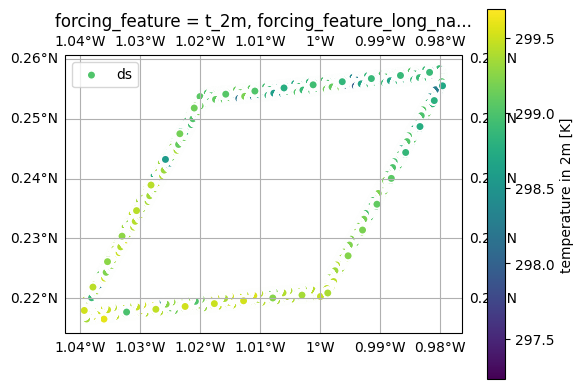

In [16]:
fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

# xr.plot.scatter(ax=ax, hue='state', ds=ds_interior[['state']].isel(state_feature=1, time=0), x="lon", y="lat", label="ds", transform=ccrs.PlateCarree(), cmap='RdYlBu')
xr.plot.scatter(ax=ax, hue='forcing', ds=ds_boundary[['forcing']].isel(forcing_feature=0, time=0), x="clon", y="clat", label="ds", transform=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels=True)
ax.legend()
plt.show()

### DANRA projection example
```
extra:
  projection:
    class_name: LambertConformal
    kwargs:
      central_longitude: 25.0
      central_latitude: 56.7
      standard_parallels: [56.7, 56.7]
      globe:
        semimajor_axis: 6367470.0
        semiminor_axis: 6367470.0
````

In [4]:
clat = ds_interior.clat.mean().compute().item()
clon = ds_interior.clon.mean().compute().item()

In [5]:
extra_dict = {
    "extra": {
        "projection": {
            "class_name": "LambertConformal",
            "kwargs": {
                "central_longitude": np.rad2deg(clon),
                "central_latitude": np.rad2deg(clat),
                "standard_parallels": [np.rad2deg(clat), np.rad2deg(clat)],
                "globe": {
                    "semimajor_axis": 6367470.0,
                    "semiminor_axis": 6367470.0
                }
            }
        }
    }
}
projection_info = extra_dict["extra"]["projection"]

In [6]:
import copy
class_name = projection_info["class_name"]
ProjectionClass = getattr(ccrs, class_name)
# need to copy otherwise we modify the dict stored in the dataclass
# in-place
kwargs = copy.deepcopy(projection_info["kwargs"])

globe_kwargs = kwargs.pop("globe", {})
if len(globe_kwargs) > 0:
    kwargs["globe"] = ccrs.Globe(**globe_kwargs)
projection = ProjectionClass(**kwargs)

In [10]:
xyz =projection.transform_points(
        ccrs.PlateCarree(), np.rad2deg(ds_boundary.clon), np.rad2deg(ds_boundary.clat)
    )

In [14]:
print(f"Max: {np.max(xyz,axis=0)}")
print(f"Min: {np.min(xyz,axis=0)}")

Max: [185013.09700233 135139.68563957      0.        ]
Min: [-187664.36924009 -133405.12895878       0.        ]


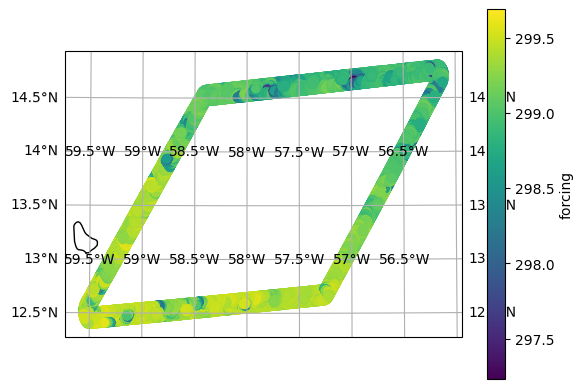

In [15]:
fig, ax = plt.subplots(subplot_kw=dict(projection=projection))
sc = ax.scatter(xyz[:, 0], xyz[:, 1], c=ds_boundary['forcing'].isel(forcing_feature=0, time=0), cmap='viridis')
ax.coastlines()
ax.gridlines(draw_labels=True)
plt.colorbar(sc, ax=ax, label='forcing')
plt.show()